# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

In [1]:
# Import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
from scipy.optimize import curve_fit

In [2]:
# Loading the datasheet
df = pd.read_csv("tempmetingen.csv", delimiter=";")

# Splitsing the colums into seperate variables
time = df["t (min)"]
temp = df["t (oC)"]

In [3]:
# Defining a function for the first 10 measurements
def first_10():
    return a*x+b

<>:17: SyntaxWarning: invalid escape sequence '\c'
<>:17: SyntaxWarning: invalid escape sequence '\c'
C:\Users\LMJBi\AppData\Local\Temp\ipykernel_12004\2073040625.py:17: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("T ($^\circ$C)")


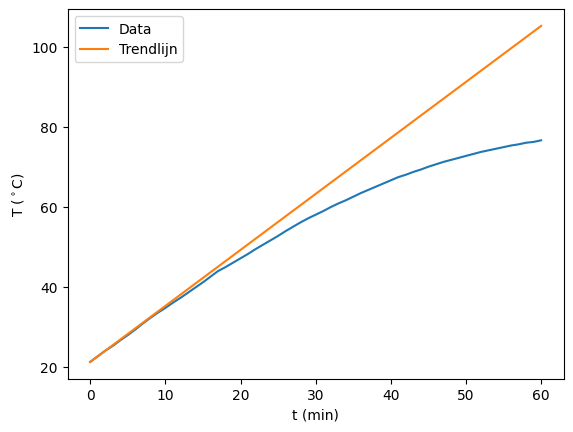

0.02266666666666667 21.200000000000003


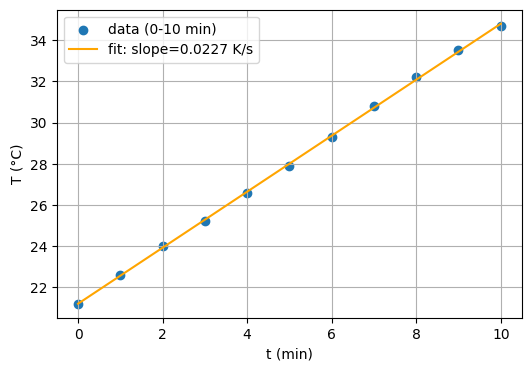

Vermogen van de heater: 44.72990133333334 Watt, Energie toegevoegd * 1uur: 161027.6448 Joule
Energie toegevoegd om het water te verwarmen: 105156.84519999998
Energie toegevoegd om het water te verdampen: 40680.00000000004
Energie verlies aan de omgeving: 15190.799599999991 Joule
Het rendement van het proces(opwarming en verdamping van het water) is: 90.56634056911948 procent


In [4]:
# Parameters
P = 46.04548                                        # Vermogen (W)
labda_verdamping = 2.26e6                           # Labda 
c = 4180                                            # Soortelijke warmte (J/(Kkg))
massa_begin=0.4721                                  # Massa (kg)
massa_eind = 0.4541
massa_verdampt = massa_begin-massa_eind

x = np.linspace(0, 60, 60)
y = P/(c*massa_begin)*x*60 + 21.2

# Plot
plt.figure()
plt.plot(time, temp, label="Data")
plt.plot(x,y, label="Trendlijn")
plt.xlabel("t (min)")
plt.ylabel("T ($^\circ$C)")
plt.legend()
plt.show()

mask = time <= 10
t_lin = time[mask] * 60   # minuten → seconden
T_lin = temp[mask]

# lineaire fit: T = a*t + b
a, b = np.polyfit(t_lin, T_lin, 1)
print(a,b)

# 3. Visualiseer fit
plt.figure(figsize=(6,4))
plt.scatter(t_lin/60, T_lin, label="data (0-10 min)")
plt.plot(t_lin/60, a*t_lin + b, label=f"fit: slope={a:.4f} K/s", color="orange")
plt.xlabel("t (min)")
plt.ylabel("T (°C)")
plt.legend()
plt.grid(True)
plt.show()

# Waardes
Totaal_vermogen = c*massa_begin*a
Totaal_toegevoegd = Totaal_vermogen *3600
print(f"Vermogen van de heater: {Totaal_vermogen} Watt, Energie toegevoegd * 1uur: {Totaal_toegevoegd} Joule") # in Joule

E_water = c*massa_eind*(temp[60]-temp[0])
print(f"Energie toegevoegd om het water te verwarmen: {E_water}")

E_verdampt = labda_verdamping*massa_verdampt
print(f"Energie toegevoegd om het water te verdampen: {E_verdampt}")

E_verlies = Totaal_toegevoegd-E_water-E_verdampt
print(f"Energie verlies aan de omgeving: {E_verlies} Joule")

rendement = (Totaal_toegevoegd-E_verlies)/Totaal_toegevoegd *100
print(f'Het rendement van het proces(opwarming en verdamping van het water) is: {rendement} procent')

**Trendlijn**

De trendlijn is berekend onder de aanname dat alle toegevoegde energie uitsluitend wordt gebruikt voor het opwarmen van het water zonder waterverlies of verdaming. 
<br> Echter heeft dat als gevolg dat de fitlijn steeds verder gaat afwijken van de meetpunten, doordat er in werkelijkheid steeds meer warmte verloren gaat naarmate het experiment langer doorloopt.
<br> Om hiermee rekening te houden, zijn alleen de metingen van de eerste 10 minuten van het experiment genomen, aangezien de fit voor dit interval grotendeels en lineair de meetpunten volgt.

**Energie**

Met behulp van de trendlijn en aannames is er berekend hoeveel van de toegevoegde energie daadwerkelijk in de opwarming en verdamping van het water zit.
<br> Na bereking blijkt dat uiteindelijk 90.6% van de toegevoegde energie gaat zitten in de opwarming en verdamping van het water. Dit betekend dat 9.4% van de warmte is ontsnapt naar de omgeving en dus niet meer in het systeem zit.

**Aanbevelingen**

Er zijn meerdere mogelijkheden om het experiment te verbeteren.
<br> Ten eerste kan de warmtestroming en de straling ook berekent worden. Hiervoor kunnen de formules $Q = \lambda \cdot A \cdot t \cdot \frac{\Delta T}{d}$ en $Q = \sigma \cdot \epsilon \cdot A \cdot t \cdot T^{4}$ respectievelijk gebruikt worden.
<br> Daarnaast kan er ook gekeken worden naar een betere isolatie van de proef, zodat er minder warmte het systeem kan verlaten. Denk hierbij aan een geisoleerde beker in plaats van glas. Daarbij is een kleinere opening waar alleen de thermometer doorheen past ook een goede optie.